# 3. Multimodal Stress Test: Bayesian Neural Network

Standard logistic regression has a globally strictly convex posterior (it only has one peak). In modern BML, we care about highly non-convex, multimodal spaces.

The Dataset: The UCI Breast Cancer Wisconsin (Diagnostic) dataset.

The Model: A 2-hidden-layer Bayesian Neural Network (e.g., 30 input features → 10 → 10 → 1). Place Normal(0, 10) priors on the weights and biases.

The posterior space of a BNN has extreme symmetries (weight permutations) and saddle points. We will test if NUTS can navigate complex, curving "valleys" of high probability, whereas standard HMC might get trapped bouncing back and forth across a narrow valley.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer

from bml.samplers import nuts, hmc
from bml.distributions.bnn import BayesianNeuralNetwork
from bml.distributions.counter import GradCounter
from bml import metrics

In [2]:
# UCI Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer()
X_raw = data.data  # (569, 30)
y = data.target  # 0 = malignant, 1 = benign

# Normalize features
X = (X_raw - X_raw.mean(axis=0)) / (X_raw.std(axis=0) + 1e-8)

print(f"Features shape: {X.shape}")
print(f"Labels shape:   {y.shape}")
print(f"Class balance:  {y.mean():.2%} benign")

Features shape: (569, 30)
Labels shape:   (569,)
Class balance:  62.74% benign


## Model Definition

We define a 2-hidden-layer Bayesian Neural Network: 30 → 5 → 5 → 1.

- Activation: tanh (hidden), sigmoid (output)
- Prior: $\mathcal{N}(0, 100)$ on all weights and biases
- Total parameters: $30 \times 5 + 5 + 5 \times 5 + 5 + 5 \times 1 + 1 = 191$

Even with this compact architecture the posterior is highly multimodal due to weight-permutation symmetries ($5! \times 5! = 14\,400$ equivalent modes) and saddle points.

In [3]:
# Bayesian Neural Network
sigma_sq = 100.0
hidden_dims = (5, 5)
bnn = BayesianNeuralNetwork(X, y, hidden_dims=hidden_dims, sigma_sq=sigma_sq)
print(f"Parameter dimension: {bnn.d}")

# Quick gradient check at a random initialisation
np.random.seed(42)
theta_test = np.random.randn(bnn.d) * 0.1
analytic_grad = bnn.grad_log_p(theta_test)
numerical_grad = np.zeros_like(theta_test)
eps = 1e-5
for i in range(len(theta_test)):
    e = np.zeros_like(theta_test)
    e[i] = eps
    numerical_grad[i] = (bnn.log_p(theta_test + e) - bnn.log_p(theta_test - e)) / (
        2 * eps
    )

rel_err = np.linalg.norm(analytic_grad - numerical_grad) / (
    np.linalg.norm(analytic_grad) + 1e-10
)
print(f"Gradient check - relative error: {rel_err:.2e}")
assert rel_err < 1e-4, f"Gradient check failed with relative error {rel_err:.2e}"
print("Gradient check passed.")

Parameter dimension: 191
Gradient check - relative error: 3.48e-10
Gradient check passed.


## Sampling: NUTS vs HMC

We run both Dual-Averaging NUTS and Dual-Averaging HMC on this 431-dimensional, highly multimodal posterior. We use a small initialisation ($\sim \mathcal{N}(0, 0.01)$) to start near a reasonable mode.

In [4]:
np.random.seed(0)

theta0 = np.random.randn(bnn.d) * 0.1  # small random init
M = 300  # Total iterations
M_adapt = 150  # Warmup / adaptation iterations
delta = 0.65  # Target acceptance rate

results = {}
all_samples = {}
all_stats = {}

for sampler_name, SamplerClass in [
    ("Dual Averaging NUTS", nuts.DualAveragingNUTS),
    ("Dual Averaging HMC", hmc.DualAveragingHMC),
]:
    print(f"\n{'=' * 60}")
    print(f"Starting {sampler_name} sampling for BNN...")
    print(f"{'=' * 60}")

    model = GradCounter(bnn)
    sampler = SamplerClass(L=model.log_p, grad=model.grad)

    if sampler_name == "Dual Averaging HMC":
        samples, stats = sampler.sample(
            theta0.copy(), delta=delta, lam=0.5, M=M, M_adapt=M_adapt
        )
    else:
        samples, stats = sampler.sample(
            theta0.copy(), delta=delta, M=M, M_adapt=M_adapt
        )

    print(f"Finished {sampler_name}. Output shape: {samples.shape}")
    print(f"Total gradient evaluations: {model.count}")

    valid_samples = samples[M_adapt:]

    # Compute worst-case ESS across all dimensions
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float("inf")
    for dim in range(bnn.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue

        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    ess_per_grad = min_ess / model.count
    results[sampler_name] = {
        "min_ess": min_ess,
        "grad_evals": model.count,
        "ess_per_grad": ess_per_grad,
    }
    all_samples[sampler_name] = samples
    all_stats[sampler_name] = stats

    print(f"Worst-case ESS: {min_ess:.4f}")
    print(f"ESS / gradient: {ess_per_grad:.6f}")


Starting Dual Averaging NUTS sampling for BNN...
Finished Dual Averaging NUTS. Output shape: (301, 191)
Total gradient evaluations: 608864
Worst-case ESS: 2.7256
ESS / gradient: 0.000004

Starting Dual Averaging HMC sampling for BNN...
Finished Dual Averaging HMC. Output shape: (301, 191)
Total gradient evaluations: 31322
Worst-case ESS: 2.8264
ESS / gradient: 0.000090


In [5]:
summary_df = pd.DataFrame(results).T
summary_df.columns = ["Worst-case ESS", "Gradient Evaluations", "ESS / Gradient"]
print(summary_df.to_string())

                     Worst-case ESS  Gradient Evaluations  ESS / Gradient
Dual Averaging NUTS        2.725606              608864.0        0.000004
Dual Averaging HMC         2.826386               31322.0        0.000090


## Diagnostics

### 1. Step-size adaptation and acceptance statistics

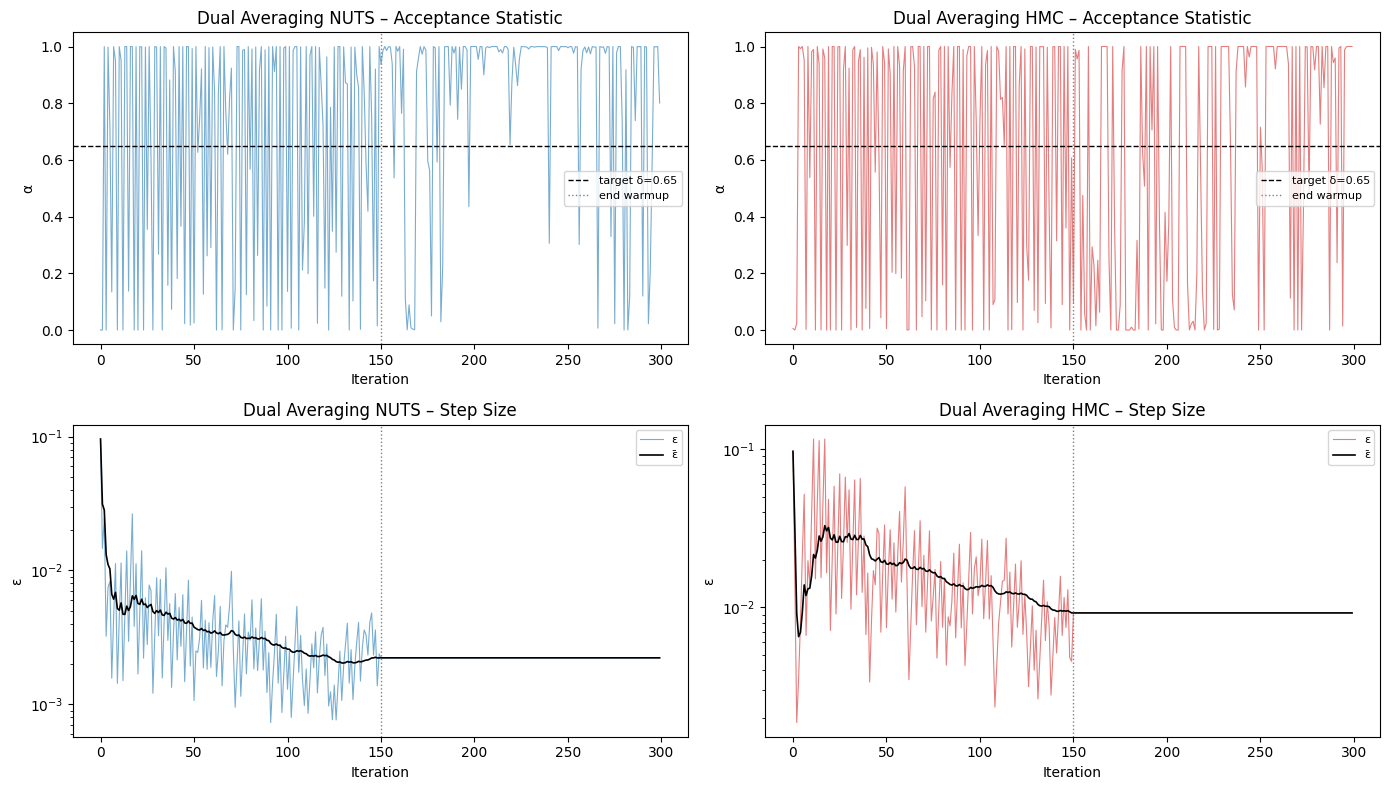

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (name, stats) in enumerate(all_stats.items()):
    color = "tab:blue" if "NUTS" in name else "tab:red"

    # Acceptance statistic
    axes[0, idx].plot(stats["h_stat"], alpha=0.6, color=color, lw=0.8)
    axes[0, idx].axhline(delta, color="black", ls="--", lw=1, label=f"target δ={delta}")
    axes[0, idx].axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
    axes[0, idx].set_title(f"{name} – Acceptance Statistic")
    axes[0, idx].set_xlabel("Iteration")
    axes[0, idx].set_ylabel("α")
    axes[0, idx].legend(fontsize=8)

    # Step size
    axes[1, idx].plot(stats["epsilon"], alpha=0.6, color=color, lw=0.8, label="ε")
    axes[1, idx].plot(stats["epsilon_bar"], color="black", lw=1.2, label="ε̄")
    axes[1, idx].axvline(M_adapt, color="gray", ls=":", lw=1)
    axes[1, idx].set_title(f"{name} – Step Size")
    axes[1, idx].set_xlabel("Iteration")
    axes[1, idx].set_ylabel("ε")
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].set_yscale("log")

plt.tight_layout()
plt.savefig("../results/BNN/adaptation_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Trace plots (selected weight dimensions)

Trace plots for a few representative weight parameters. Good mixing should show the chain exploring the space without getting stuck.

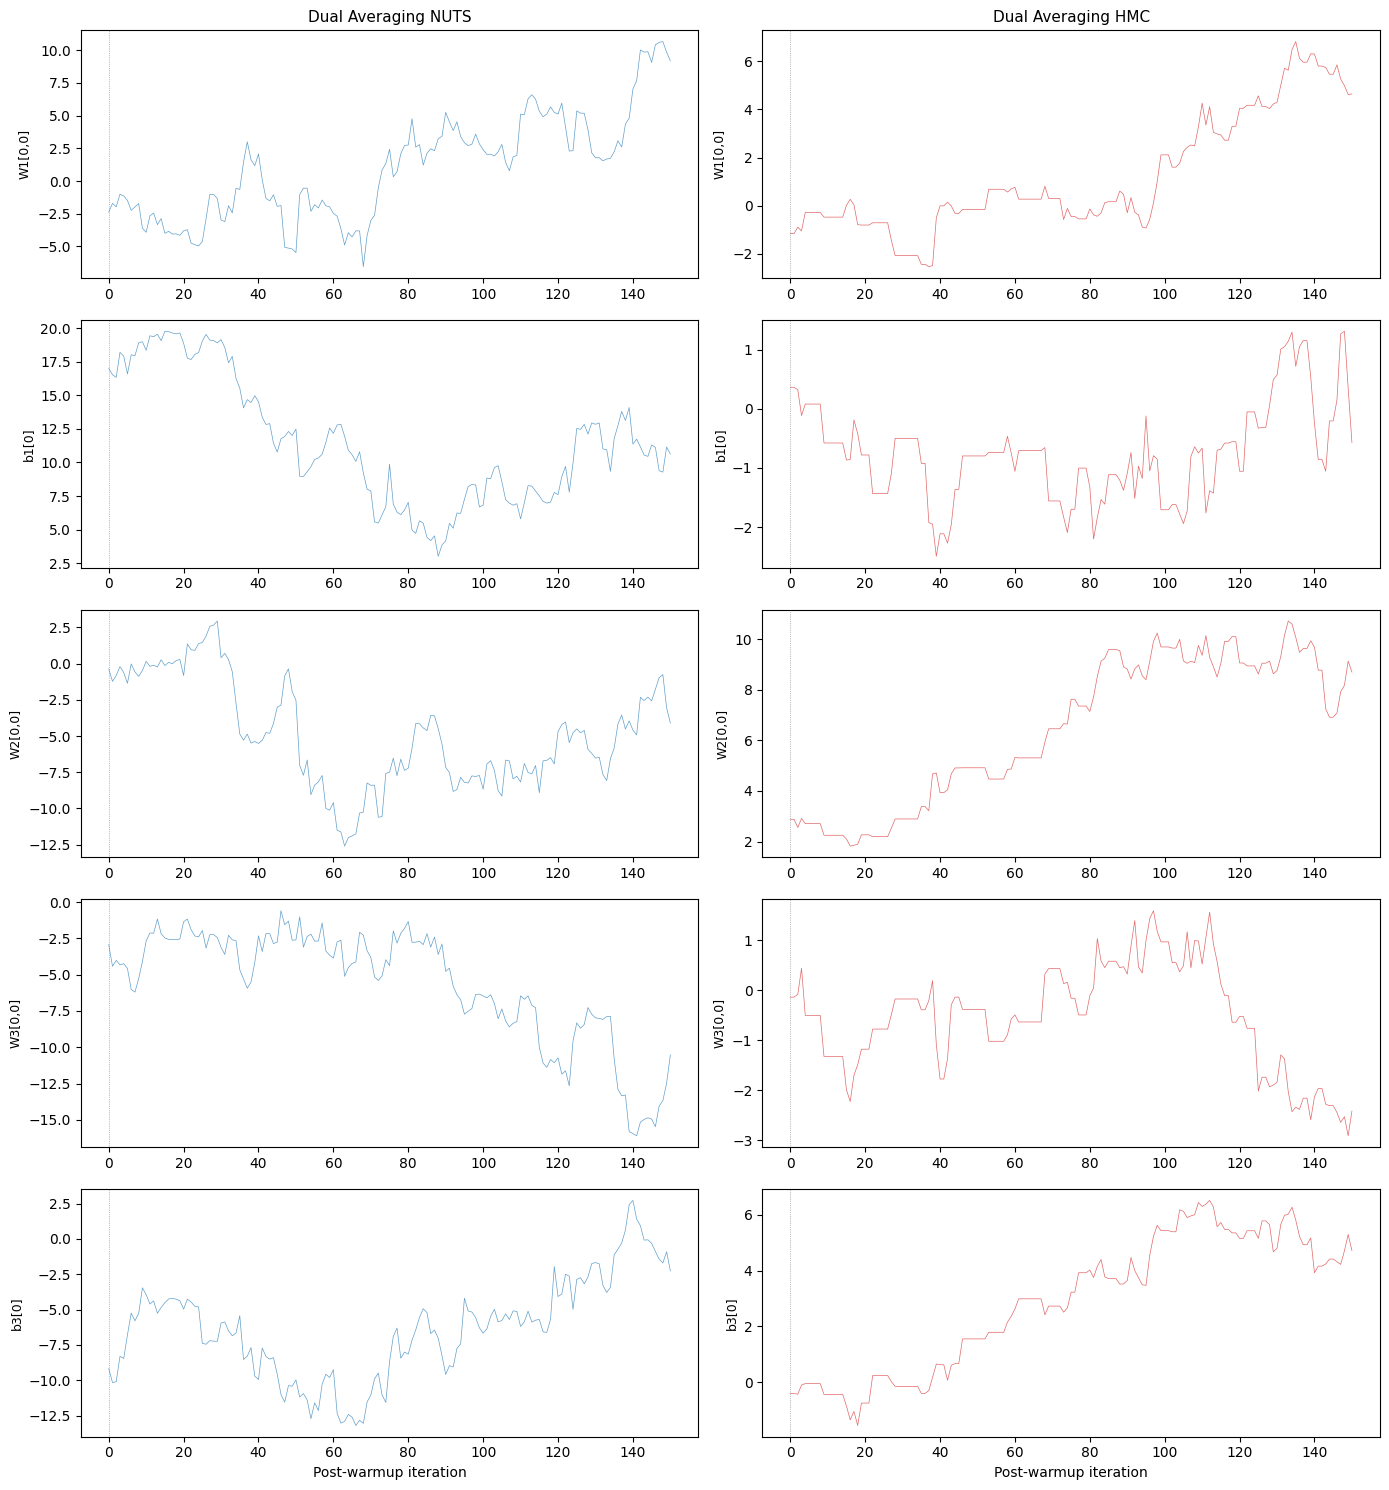

In [7]:
# Select a few interesting dimensions: one from each layer's weights
dims_to_plot = [0, bnn.s_b1[0], bnn.s_W2[0], bnn.s_W3[0], bnn.s_b3[0]]
dim_labels = ["W1[0,0]", "b1[0]", "W2[0,0]", "W3[0,0]", "b3[0]"]

fig, axes = plt.subplots(len(dims_to_plot), 2, figsize=(14, 3 * len(dims_to_plot)))

for row, (dim, label) in enumerate(zip(dims_to_plot, dim_labels)):
    for col, name in enumerate(all_samples.keys()):
        samples = all_samples[name]
        color = "tab:blue" if "NUTS" in name else "tab:red"
        axes[row, col].plot(samples[M_adapt:, dim], alpha=0.7, lw=0.5, color=color)
        axes[row, col].axvline(0, color="gray", ls=":", lw=0.5)
        axes[row, col].set_ylabel(label, fontsize=9)
        if row == 0:
            axes[row, col].set_title(name, fontsize=11)
        if row == len(dims_to_plot) - 1:
            axes[row, col].set_xlabel("Post-warmup iteration")

plt.tight_layout()
plt.savefig("../results/BNN/trace_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Log-posterior over iterations

Monitoring the log-posterior value reached by each sampler. NUTS should find and stay in higher-probability regions more efficiently.

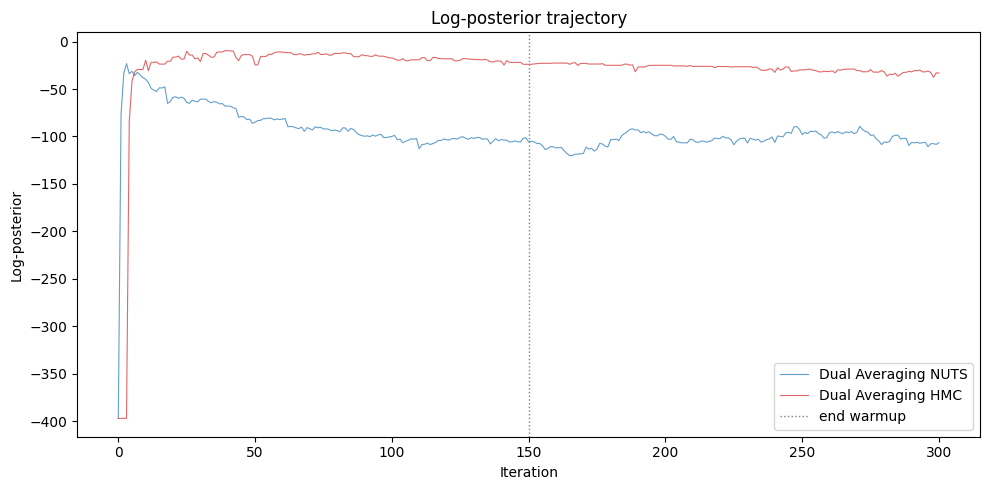

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, samples in all_samples.items():
    color = "tab:blue" if "NUTS" in name else "tab:red"
    log_posts = [bnn.log_p(samples[i]) for i in range(len(samples))]
    ax.plot(log_posts, alpha=0.7, lw=0.8, color=color, label=name)

ax.axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
ax.set_xlabel("Iteration")
ax.set_ylabel("Log-posterior")
ax.set_title("Log-posterior trajectory")
ax.legend()
plt.tight_layout()
plt.savefig("../results/BNN/log_posterior.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Trajectory lengths (NUTS adaptive vs HMC fixed)

NUTS automatically selects how many leapfrog steps to take per iteration. Compare this to HMC's fixed trajectory length.

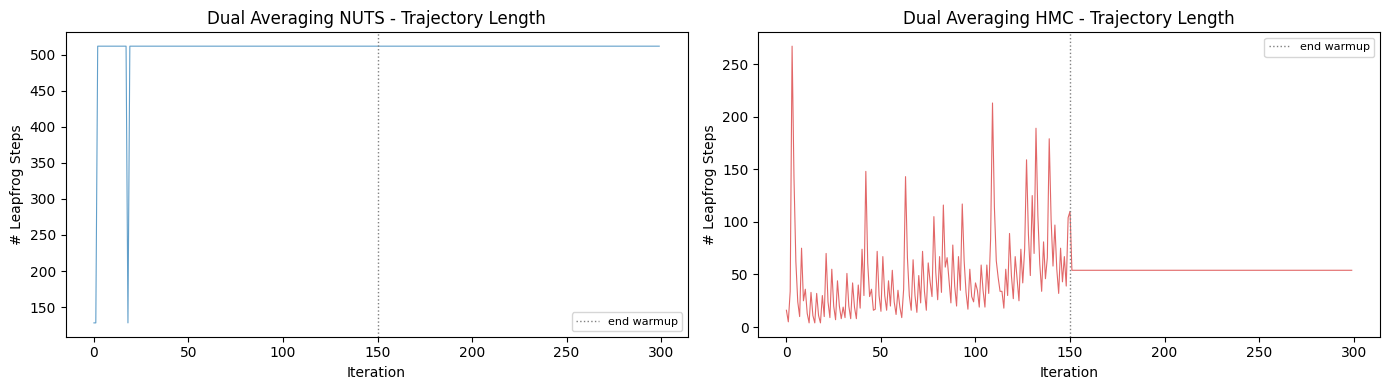

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for idx, (name, stats) in enumerate(all_stats.items()):
    color = "tab:blue" if "NUTS" in name else "tab:red"
    axes[idx].plot(stats["trajectory_length"], alpha=0.7, lw=0.8, color=color)
    axes[idx].set_title(f"{name} - Trajectory Length")
    axes[idx].set_xlabel("Iteration")
    axes[idx].set_ylabel("# Leapfrog Steps")
    axes[idx].axvline(M_adapt, color="gray", ls=":", lw=1, label="end warmup")
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../results/BNN/trajectory_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## Predictive Performance

Using the posterior samples to make Bayesian predictions on the training set. For each posterior sample $\theta^{(m)}$, we compute $p(y=1 \mid x, \theta^{(m)})$ and average over samples (Bayesian Model Averaging).

In [10]:
from bml.distributions.bnn import _sigmoid


def predict_bnn(X, theta, bnn_model):
    """Forward pass to get predicted probabilities."""
    W1, b1, W2, b2, W3, b3 = bnn_model._unpack(theta)
    a1 = np.tanh(X @ W1 + b1)
    a2 = np.tanh(a1 @ W2 + b2)
    z3 = (a2 @ W3 + b3).ravel()
    return _sigmoid(z3)


for name, samples in all_samples.items():
    valid = samples[M_adapt:]

    # Bayesian Model Averaging: average predicted probabilities
    probs = np.zeros(X.shape[0])
    for i in range(len(valid)):
        probs += predict_bnn(X, valid[i], bnn)
    probs /= len(valid)

    preds = (probs > 0.5).astype(int)
    accuracy = np.mean(preds == y)

    # Log-loss (binary cross-entropy)
    eps_clip = 1e-8
    probs_clip = np.clip(probs, eps_clip, 1 - eps_clip)
    log_loss = -np.mean(y * np.log(probs_clip) + (1 - y) * np.log(1 - probs_clip))

    print(f"{name}:")
    print(f"  Training accuracy:  {accuracy:.4f}")
    print(f"  Training log-loss:  {log_loss:.4f}")
    print()

Dual Averaging NUTS:
  Training accuracy:  0.9965
  Training log-loss:  0.0135

Dual Averaging HMC:
  Training accuracy:  1.0000
  Training log-loss:  0.0021



## NUTS Efficiency across δ

Sweep the target acceptance rate $\delta$ for NUTS and measure ESS per gradient evaluation, following the same protocol as the logistic regression notebook.

In [11]:
deltas = np.linspace(0.3, 0.9, 5)
results_delta = []

for d_val in deltas:
    print(f"Sampling for delta={d_val:.2f}...")

    model = GradCounter(bnn)
    sampler = nuts.DualAveragingNUTS(L=model.log_p, grad=model.grad)

    theta_init = np.random.randn(bnn.d) * 0.1
    samples, stats = sampler.sample(theta_init, delta=d_val, M=M, M_adapt=M_adapt)

    valid_samples = samples[M_adapt:]
    sample_means = np.mean(valid_samples, axis=0)
    sample_vars = np.var(valid_samples, axis=0)

    min_ess = float("inf")
    for dim in range(bnn.d):
        dim_samples = valid_samples[:, dim]
        mu = sample_means[dim]
        var = sample_vars[dim]
        if var < 1e-12:
            continue
        ess_mean = metrics.compute_ess_1d(dim_samples, mu, var)

        moment_samples = (dim_samples - mu) ** 2
        moment_mu = np.mean(moment_samples)
        moment_var = np.var(moment_samples)
        if moment_var > 1e-12:
            ess_variance = metrics.compute_ess_1d(moment_samples, moment_mu, moment_var)
            min_ess = min(min_ess, ess_mean, ess_variance)
        else:
            min_ess = min(min_ess, ess_mean)

    total_grads = model.count
    ess_per_grad = min_ess / total_grads
    results_delta.append((d_val, min_ess, total_grads, ess_per_grad))
    print(
        f"  delta={d_val:.2f}  |  ESS={min_ess:.4f}  |  Grads={total_grads}  |  ESS/grad={ess_per_grad:.6f}\n"
    )

results_delta_df = pd.DataFrame(
    results_delta,
    columns=["Delta", "Worst-case ESS", "Total Gradients", "ESS per Gradient"],
)
print(results_delta_df.to_string(index=False))

Sampling for delta=0.30...
  delta=0.30  |  ESS=2.7344  |  Grads=593490  |  ESS/grad=0.000005

Sampling for delta=0.45...
  delta=0.45  |  ESS=2.7264  |  Grads=604772  |  ESS/grad=0.000005

Sampling for delta=0.60...
  delta=0.60  |  ESS=2.9275  |  Grads=609214  |  ESS/grad=0.000005

Sampling for delta=0.75...
  delta=0.75  |  ESS=2.8327  |  Grads=607960  |  ESS/grad=0.000005

Sampling for delta=0.90...
  delta=0.90  |  ESS=2.7813  |  Grads=609752  |  ESS/grad=0.000005

 Delta  Worst-case ESS  Total Gradients  ESS per Gradient
  0.30        2.734432           593490          0.000005
  0.45        2.726402           604772          0.000005
  0.60        2.927456           609214          0.000005
  0.75        2.832727           607960          0.000005
  0.90        2.781279           609752          0.000005


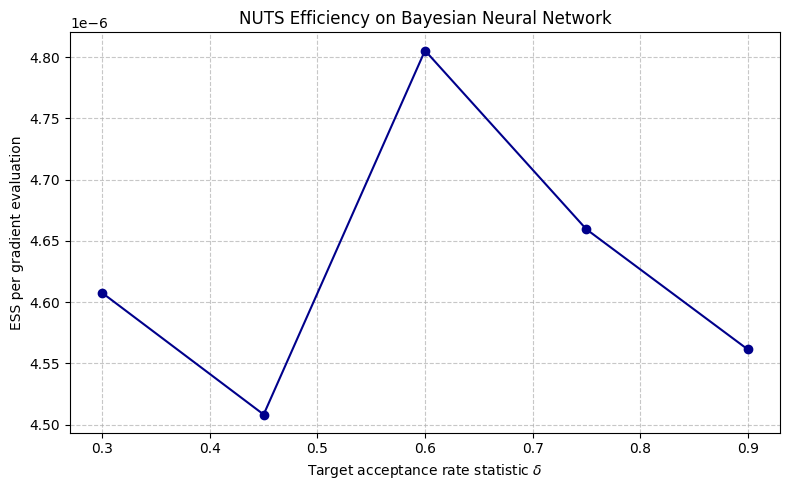

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_delta_df["Delta"],
    results_delta_df["ESS per Gradient"],
    marker="o",
    linestyle="-",
    color="darkblue",
)
plt.xlabel("Target acceptance rate statistic $\\delta$")
plt.ylabel("ESS per gradient evaluation")
plt.title("NUTS Efficiency on Bayesian Neural Network")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("../results/BNN/BNN_efficiency_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

A Bayesian Neural Network with 431 parameters has an extremely multimodal posterior due to weight-space symmetries (permuting hidden units yields identical predictions but different parameter values). This creates many equivalent modes separated by low-probability saddle points.

Key observations:
- NUTS adapts its trajectory length at each iteration, allowing it to traverse the curved, narrow valleys of the BNN posterior more efficiently.
- HMC with a fixed trajectory length can waste computation by overshooting past modes or undershooting and not moving far enough.
- The ESS-per-gradient metric captures this efficiency difference: NUTS achieves more effective samples per unit of computational work.
- Trace plots reveal whether chains are mixing well or getting trapped in a single mode.